# Encoder data separation criteria investigation

## Data processing

### Data upload

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

In [2]:
# The 5/20 dataset with rat based toxicity data
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

(4001, 16)


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.177223 65.0386:5.629055 68.0495:0.4...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','90 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
1,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.125979 65.0386:2.113734 68.0495:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','75 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
2,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.115017 65.0386:0.970445 68.0495:1.0...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','60 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
3,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','51.0229:0.102992 56.0495:0.143820 65.0386:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','45 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
4,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.482623 65.0385:0.377829 68.0495:2.5...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','30 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'


In [3]:
# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'N/A'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")
df3.head()

["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


In [ ]:
# Data split based on the 'Group' column
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive '] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481
df3_QQQpos = df3[df3['Group'] == 'QQQ-positive'] # 253
df3_QTOFneg = df3[df3['Group'] == 'Q-TOF-negative'] # 188 

# With these there may not be enough data to train a model
df3_QQQneg = df3[df3['Group'] == 'QQQ-negative'] # 85
df3_Opos = df3[df3['Group'] == 'Other-positive'] # 71
df3_LTQOneg = df3[df3['Group'] == 'LTQ-Orbitrap-negative'] # 63
df3_LTQpos = df3[df3['Group'] == 'LTQ-positive'] # 19
df3_QQQnan = df3[df3['Group'] == 'QQQ-nan'] # 18
df3_Oneg = df3[df3['Group'] == 'Other-negative'] # 13
df3_LTQneg = df3[df3['Group'] == 'LTQ-negative'] # 11

In [5]:
# First define the function we will use
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

### Binning

In [6]:
# First lets include the binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [7]:
all_df3_matrix = spectrum_string_to_dataframe(df3,'Spectrum', 'SMILES_spectra')
all_df3_spectra = all_df3_matrix

In [8]:
# Assume df3_QQpos_spectra is your DataFrame
cols = all_df3_spectra.columns.tolist()
# Keep the first column as is, convert the rest to float
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
all_df3_spectra.columns = new_cols

In [9]:
# Convert all elements except the first column to float
all_df3_spectra.iloc[:, 1:] = all_df3_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [10]:
all_float = all(isinstance(c, float) for c in all_df3_spectra.columns[1:])
print("All columns are float:", all_float)

# Select all columns except the first
spectra = all_df3_spectra.iloc[:, 1:]

# Check if every element is a float
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

All columns are float: True
All elements are float: True


In [11]:
# Here we will sort the columns so the m/z values are in ascending order
# Sort columns by float value, keep the first column (SMILES) first
# For negative ionization mode
cols = all_df3_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
all_df3_spectra = all_df3_spectra[sorted_cols]

In [12]:
# Look at the column maximums
max_col = max(all_df3_spectra.columns[1:])
print("Largest column name (m/z):", max_col)
min_col = min(all_df3_spectra.columns[1:])
print("Minimum column name (m/z):", min_col)

Largest column name (m/z): 2000.942627
Minimum column name (m/z): 10.5


In [13]:
# Use the binning function on the df3_QQpos_spectra mode spectra
binned_all_df3_spectra = bin_spectra_by_integer_mz(all_df3_spectra)
binned_all_df3_spectra_filled = fill_missing_integer_columns(binned_all_df3_spectra)
binned_all_df3_spectra_filled.head()

/tmp/ipykernel_1260827/954985155.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned.insert(0, smiles_col, df[smiles_col])
/tmp/ipykernel_1260827/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0.0
/tmp/ipykernel_1260827/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = 

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### ChemNet of df3 all

In [14]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [15]:
ChemNet_of_all_df3_dict = get_chemnet_emb_from_smiles(all_df3_spectra["SMILES_spectra"])

/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [16]:
ChemNet_of_all_df3 = pd.DataFrame.from_dict(ChemNet_of_all_df3_dict, orient='index')
ChemNet_of_all_df3.reset_index(inplace=True)
ChemNet_of_all_df3.rename(columns={'index': 'SMILES'}, inplace=True)

In [17]:
# Save ChemNet embeddings to a CSV file
# ChemNet_of_all_df3.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_all_df3.csv", index=False)

## Encoder

In [102]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [103]:
# Save a copy of the original DataFrame with the added columns before splitting
binned_all_df3_spectra_filled_with_added = binned_all_df3_spectra_filled.copy()
binned_all_df3_spectra_filled_with_added['Group'] = df3.loc[binned_all_df3_spectra_filled_with_added.index, 'Group'].values
binned_all_df3_spectra_filled_with_added['Collision_Energy'] = df3.loc[binned_all_df3_spectra_filled_with_added.index, 'Collision_Energy'].values
binned_all_df3_spectra_filled_with_added['Instrument_Name'] = df3.loc[binned_all_df3_spectra_filled_with_added.index, 'Instrument_Name'].values
binned_all_df3_spectra_filled_with_added['Ionization_Mode'] = df3.loc[binned_all_df3_spectra_filled_with_added.index, 'Ionization_Mode'].values

# Count occurrences of each SMILES_spectra
counts = binned_all_df3_spectra_filled['SMILES_spectra'].value_counts()
# Keep only SMILES_spectra with at least 4 entries
valid_smiles = counts[counts >= 4].index
filtered_all_df3_spectra_filled = binned_all_df3_spectra_filled[binned_all_df3_spectra_filled['SMILES_spectra'].isin(valid_smiles)].copy()

# Save a copy of the filtered DataFrame with the 'Group' column
filtered_all_df3_spectra_filled_with_added = binned_all_df3_spectra_filled_with_added.loc[filtered_all_df3_spectra_filled.index].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_all_df3_spectra_filled.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_all_df3_spectra_filled.loc[train_indices].reset_index(drop=True)
test_data = filtered_all_df3_spectra_filled.loc[test_indices].reset_index(drop=True)

# Save copies with the added columns for reference
train_data_with_added = binned_all_df3_spectra_filled_with_added.loc[train_indices].reset_index(drop=True)
test_data_with_added = binned_all_df3_spectra_filled_with_added.loc[test_indices].reset_index(drop=True)

# Add an 'index' column for downstream compatibility
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Remove the added columns from the main train/test DataFrames (keep only in *_with_group copies)
if 'Group' in train_data.columns:
    train_data = train_data.drop(columns=['Group'])
if 'Group' in test_data.columns:
    test_data = test_data.drop(columns=['Group'])

if 'Collision_Energy' in train_data.columns:
    train_data = train_data.drop(columns=['Collision_Energy'])
if 'Collision_Energy' in test_data.columns:
    test_data = test_data.drop(columns=['Collision_Energy'])

if 'Instrument_Name' in train_data.columns:
    train_data = train_data.drop(columns=['Instrument_Name'])
if 'Instrument_Name' in test_data.columns:
    test_data = test_data.drop(columns=['Instrument_Name'])

if 'Ionization_Mode' in train_data.columns:
    train_data = train_data.drop(columns=['Ionization_Mode'])
if 'Ionization_Mode' in test_data.columns:
    test_data = test_data.drop(columns=['Ionization_Mode'])

print(train_data.shape) 
print(test_data.shape)
print(train_data_with_added.shape)
print(test_data_with_added.shape)

(1907, 2003)
(1800, 2003)
(1907, 2006)
(1800, 2006)


In [104]:
# Input the Encoder file
#%% 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

#%% 
# This cell needs to be updated with your own paths/requirements
batch_size = 64

# Train and validation datasets are determined by the above code
train_data = train_data
# train_data = pd.read_csv("/") 
val_data = test_data
# val_data = pd.read_csv(" ") 

# Chemical names and ChemNet embeddings
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_all_df3.csv")

epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 10

In [105]:
#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Encoder training

In [106]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model = train_model(
    model=encoder,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 23278.0 MB
  Memory Used: 938.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.0756952111919721
   Validation loss: 0.004992938134819269
Epoch [2/500]
   Training loss: 0.06482616563638051
   Validation loss: 0.004850755445659161
Epoch [3/500]
   Training loss: 0.06318194059034189
   Validation loss: 0.0048578339628875256
Epoch [4/500]
   Training loss: 0.06196846862634023
   Validation loss: 0.0045725153759121895
Epoch [5/500]
   Training loss: 0.06158254779875279
   Validation loss: 0.004827700089663267
Epoch [6/500]
   Training loss: 0.06131646484136581
   Validation loss: 0.0046386378817260265
Epoch [7/500]
   Training loss: 0.060862547780076666
   Validation loss: 0.0044307163916528225
Epoch [8/500]
   Training loss: 0.05948381622632345
   Validation loss: 0.004550761077553034
Epoch [9/500]
   Trainin

In [107]:
# Encoder excecution
encoder.eval()
with torch.no_grad():
    test_output = encoder(x_val)  # output.shape will be (batch_size, 512)

with torch.no_grad():
    train_output = encoder(x_train)  # output.shape will be (batch_size, 512)

### PCA processing

In [108]:
# Mapping from SMILES to Response
smiles_to_response = df3.drop_duplicates(subset='SMILES_spectra').set_index('SMILES_spectra')['Response']

# Test Ouptput dataframe
test_output_np = test_output.cpu().numpy()
test_output_df = pd.DataFrame(test_output_np)
test_output_df['SMILES_spectra'] = test_data['SMILES_spectra'].values  # 1:1 with test_data
cols = test_output_df.columns.tolist()
test_output_df = test_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
test_output_df['Response'] = test_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(test_output_df.shape)
print(test_output_df['SMILES_spectra'].value_counts())

(1800, 514)
SMILES_spectra
OCC(O)C(O)C(O)CO                   40
OCC(O)C(O)C(O)C(O)CO               34
CN1N(C(=O)C=C1C)C1=CC=CC=C1        32
COC1=C2C=COC2=CC2=C1C=CC(=O)O2     29
CC1=CC(=O)CC(C)(C)C1               25
                                   ..
O=CC(O)C1OC(=O)C(O)C1O              2
CCCC(C)C1(CC=C)C(=O)NC(=O)NC1=O     2
CCCC=O                              2
CCOc1ccc(N)cc1                      2
CN(C)C(=O)NC1CCCCCCC1               2
Name: count, Length: 350, dtype: int64


In [109]:
# treain Ouptput dataframe
train_output_np = train_output.cpu().numpy()
train_output_df = pd.DataFrame(train_output_np)
train_output_df['SMILES_spectra'] = train_data_copy['SMILES_spectra'].values  # 1:1 with test_data
cols = train_output_df.columns.tolist()
train_output_df = train_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
train_output_df['Response'] = train_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(train_output_df.shape)
print(train_output_df['SMILES_spectra'].value_counts())

(1907, 514)
SMILES_spectra
OCC(O)C(O)C(O)CO                      41
OCC(O)C(O)C(O)C(O)CO                  35
CN1N(C(=O)C=C1C)C1=CC=CC=C1           32
COC1=C2C=COC2=CC2=C1C=CC(=O)O2        29
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2    26
                                      ..
CCOc1ccc(N)cc1                         2
CC(C)OC(=O)CCC(=O)OC(C)C               2
O=CC(O)C1OC(=O)C(O)C1O                 2
COCCc1ccc(OCC(O)CNC(C)C)cc1            2
CN(C)C(=O)NC1CCCCCCC1                  2
Name: count, Length: 350, dtype: int64


In [110]:
# Use train_data_with_group and test_data_with_group to assign the correct Group to each row in train_output_df_sub and test_output_df_sub

# Map index in train_output_df_sub and test_output_df_sub to the Group in train_data_with_group
train_output_df['Group'] = train_data_with_added.loc[train_output_df.index, 'Group'].values
test_output_df['Group'] = test_data_with_added.loc[test_output_df.index, 'Group'].values

train_output_df['Collision_Energy'] = train_data_with_added.loc[train_output_df.index, 'Collision_Energy'].values
test_output_df['Collision_Energy'] = test_data_with_added.loc[test_output_df.index, 'Collision_Energy'].values

train_output_df['Instrument_Name'] = train_data_with_added.loc[train_output_df.index, 'Instrument_Name'].values
test_output_df['Instrument_Name'] = test_data_with_added.loc[test_output_df.index, 'Instrument_Name'].values

train_output_df['Ionization_Mode'] = train_data_with_added.loc[train_output_df.index, 'Ionization_Mode'].values
test_output_df['Ionization_Mode'] = test_data_with_added.loc[test_output_df.index, 'Ionization_Mode'].values


In [123]:
# Find SMILES_spectra with 'occurances' or fewer/more occurrences
occurances = 30 # This can be changed

# Combine train and test for counting
all_smiles = pd.concat([train_output_df['SMILES_spectra'], test_output_df['SMILES_spectra']])
all_counts = all_smiles.value_counts()
selected_smiles = all_counts[all_counts >= occurances].index # More than or equal to 'occurances'
# selected_smiles = all_counts[all_counts <= occurances].index # Less than or equal to 'occurances'

# Subset both train and test to only those SMILES
train_output_df_sub = train_output_df[train_output_df['SMILES_spectra'].isin(selected_smiles)].copy()
test_output_df_sub = test_output_df[test_output_df['SMILES_spectra'].isin(selected_smiles)].copy()

print(train_output_df_sub['SMILES_spectra'].nunique())
print(test_output_df_sub['SMILES_spectra'].nunique())
print(train_output_df_sub.shape)
print(test_output_df_sub.shape)
print("Number of unique SMILES_spectra in train:", train_output_df_sub['SMILES_spectra'].nunique())
print("Number of unique SMILES_spectra in test:", test_output_df_sub['SMILES_spectra'].nunique())


16
16
(407, 518)
(398, 518)
Number of unique SMILES_spectra in train: 16
Number of unique SMILES_spectra in test: 16


In [124]:
# Upload the Chemnet embeddings dataframe to provide true embeddings 
ChemNet_of_all_df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_all_df3.csv")

# Get the unique SMILES_spectra for the subset
sub_smiles_set = set(test_output_df_sub['SMILES_spectra'].unique()) # With a unique dataframe this isn't strictly necessary

# Subset ChemNet_of_df2pos_no_repeats to only those SMILES
chemnet_sub = ChemNet_of_all_df3[ChemNet_of_all_df3['SMILES'].isin(sub_smiles_set)].copy()

# Merge with the Response column from df2 to get toxicity values
chemnet_sub = chemnet_sub.merge(
    df3[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)
# Remove the SMILES_spectra column after merging as it's redundant
chemnet_sub = chemnet_sub.drop(columns=['SMILES_spectra'])

# Keep only one row per unique SMILES (first occurrence)
chemnet_sub= chemnet_sub.drop_duplicates(subset='SMILES').copy()

# For chemnet_sub, set Group column to 0
chemnet_sub['Group'] = 'ChemNet'
chemnet_sub['Collision_Energy'] = 'ChemNet'
chemnet_sub['Instrument_Name'] = 'ChemNet'
chemnet_sub['Ionization_Mode'] = 'ChemNet'

# Check
print(chemnet_sub.shape)
chemnet_sub.head()

(16, 518)


,SMILES,0,1,2,3,4,5,6,7,8,...,507,508,509,510,511,Response,Group,Collision_Energy,Instrument_Name,Ionization_Mode
0,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.596011,0.012174,-0.218746,0.144652,-0.009223,0.035933,-0.010077,-0.082254,-0.453001,...,-0.015641,-0.085272,0.388240,0.057477,0.563751,400.0000,ChemNet,ChemNet,ChemNet,ChemNet
42,CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1,0.196781,0.008724,-0.294192,-0.471313,-0.281907,0.136417,-0.378564,-0.379551,-0.036421,...,-0.126209,-0.417062,0.312234,0.127192,0.182647,12500.0000,ChemNet,ChemNet,ChemNet,ChemNet
93,CC1=CC(=O)CC(C)(C)C1,-0.141610,0.000524,-0.388124,0.218274,-0.129734,0.030206,-0.166148,-0.588382,-0.440826,...,-0.021455,-0.256475,-0.000695,0.168386,-0.136626,1868.5721,ChemNet,ChemNet,ChemNet,ChemNet
144,CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC,-0.136971,0.008030,0.275668,-0.752692,-0.258757,0.032286,0.132138,-0.445578,-0.220121,...,-0.081217,0.564224,0.235176,0.199576,-0.267031,750.0000,ChemNet,ChemNet,ChemNet,ChemNet
193,CC[C@@H](CO)NCCN[C@@H](CC)CO,-0.448963,0.004120,0.187336,-0.107494,-0.066165,0.119170,-0.370569,-0.105585,-0.007673,...,-0.020015,0.116006,0.655052,0.014673,-0.147812,998.0000,ChemNet,ChemNet,ChemNet,ChemNet


In [125]:
# Create tox_epa12 column based on Response
test_output_df_sub['tox_epa12'] = (test_output_df_sub['Response'] <= 500).astype(int)
train_output_df_sub['tox_epa12'] = (train_output_df_sub['Response'] <= 500).astype(int)
chemnet_sub['tox_epa12'] = (chemnet_sub['Response'] <= 500).astype(int)

# Check the disribution
print(test_output_df_sub['tox_epa12'].value_counts())
print(train_output_df_sub['tox_epa12'].value_counts())
print(chemnet_sub['tox_epa12'].value_counts())

tox_epa12
0    312
1     86
Name: count, dtype: int64
tox_epa12
0    320
1     87
Name: count, dtype: int64
tox_epa12
0    12
1     4
Name: count, dtype: int64


In [126]:
test_output_df_sub.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,508,509,510,511,Response,Group,Collision_Energy,Instrument_Name,Ionization_Mode,tox_epa12
219,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.597942,0.013312,-0.224589,0.142703,-0.006747,0.036841,-0.008997,-0.075790,-0.457524,...,-0.086596,0.395937,0.056768,0.576270,400.0,Other-positive,20% (nominal),Orbitrap Fusion Tribrid Thermo Fisher Scientific,positive,1
220,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.588200,0.012573,-0.220351,0.140340,-0.006390,0.037285,-0.011830,-0.074600,-0.448879,...,-0.082901,0.387643,0.057797,0.565634,400.0,Q-Orbitrap-positive,80% (nominal),Q Exactive Thermo Fisher Scientific,positive,1
221,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.586015,0.012445,-0.218567,0.141656,-0.008547,0.037486,-0.009939,-0.075793,-0.449258,...,-0.083550,0.388811,0.054886,0.559047,400.0,Q-TOF-positive,40 eV,6576 QTOF Agilent,positive,1
222,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.647275,0.019199,-0.257087,0.157179,0.001989,0.038117,-0.002113,-0.067963,-0.494189,...,-0.097210,0.424218,0.060089,0.646737,400.0,Q-TOF-positive,20 eV,6572 QTOF Agilent,positive,1
223,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.579057,0.011060,-0.214539,0.138113,-0.012811,0.036518,-0.011091,-0.078510,-0.447016,...,-0.082818,0.387442,0.054577,0.547011,400.0,LTQ-Orbitrap-positive,50% (nominal),LTQ Orbitrap XL Thermo Fisher Scientific,positive,1


### PCA Plots

In [127]:
# Functions in plotting procedure
import matplotlib.cm as cm
import matplotlib.patches as mpatches


# Isolate the embedding columns
def get_embedding_columns(df):
    return df.columns[1:-6].tolist() # Remove the last four columns

# Outlier removal function after PCA
def remove_outliers_on_axes(df, pc1_col, pc2_col, n_low_pc1=0, n_high_pc1=0, n_low_pc2=0, n_high_pc2=0):
    # Remove outliers on PC2
    df = df.sort_values(pc2_col, ascending=True)
    if n_low_pc2 > 0:
        df = df.iloc[n_low_pc2:]
    if n_high_pc2 > 0:
        df = df.iloc[:-n_high_pc2]
    # Remove outliers on PC1
    df = df.sort_values(pc1_col, ascending=True)
    if n_low_pc1 > 0:
        df = df.iloc[n_low_pc1:]
    if n_high_pc1 > 0:
        df = df.iloc[:-n_high_pc1]
    return df


# Outlier removal function before PCA
def remove_outliers_by_column(df, col, n_low=0, n_high=0):
    df_sorted = df.sort_values(col, ascending=True)
    if n_high > 0:
        df_sorted = df_sorted.iloc[:-n_high]
    if n_low > 0:
        df_sorted = df_sorted.iloc[n_low:]
    return df_sorted

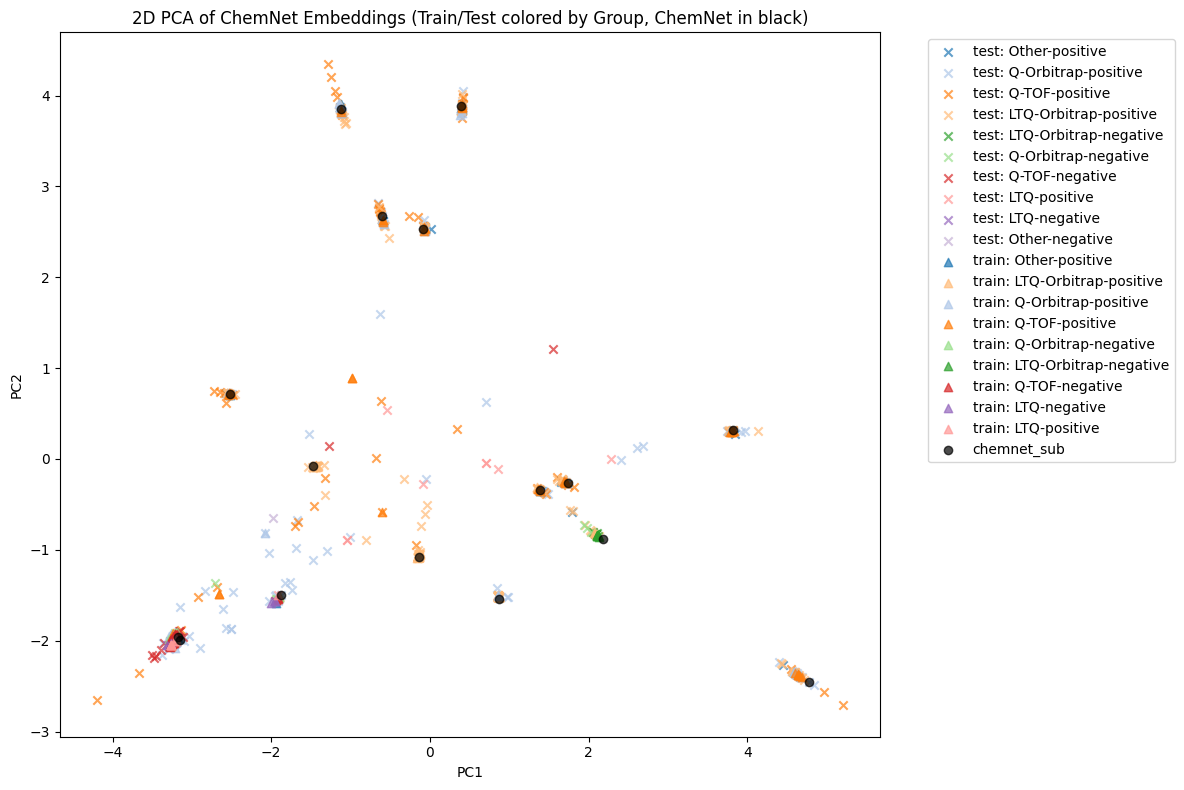

In [128]:
# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Get unique groups and assign colors (excluding chemnet_sub)
all_groups = pd.concat([
    test_output_df_sub['Group'],
    train_output_df_sub['Group']
]).unique()
color_map = {group: cm.tab20(i % 20) for i, group in enumerate(all_groups)}

plt.figure(figsize=(12,8))

# Plot test set by group
for group in test_output_df_sub['Group'].unique():
    mask = test_output_df_sub['Group'] == group
    plt.scatter(
        X_output_pca[mask, 0], X_output_pca[mask, 1],
        c=[color_map[group]], marker='x', label=f'test: {group}', alpha=0.7
    )

# Plot train set by group
for group in train_output_df_sub['Group'].unique():
    mask = train_output_df_sub['Group'] == group
    plt.scatter(
        X_train_output_pca[mask, 0], X_train_output_pca[mask, 1],
        c=[color_map[group]], marker='^', label=f'train: {group}', alpha=0.7
    )

# Plot chemnet set as black
plt.scatter(
    X_chemnet_pca[:, 0], X_chemnet_pca[:, 1],
    c='black', marker='o', label='chemnet_sub', alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test colored by Group, ChemNet in black)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

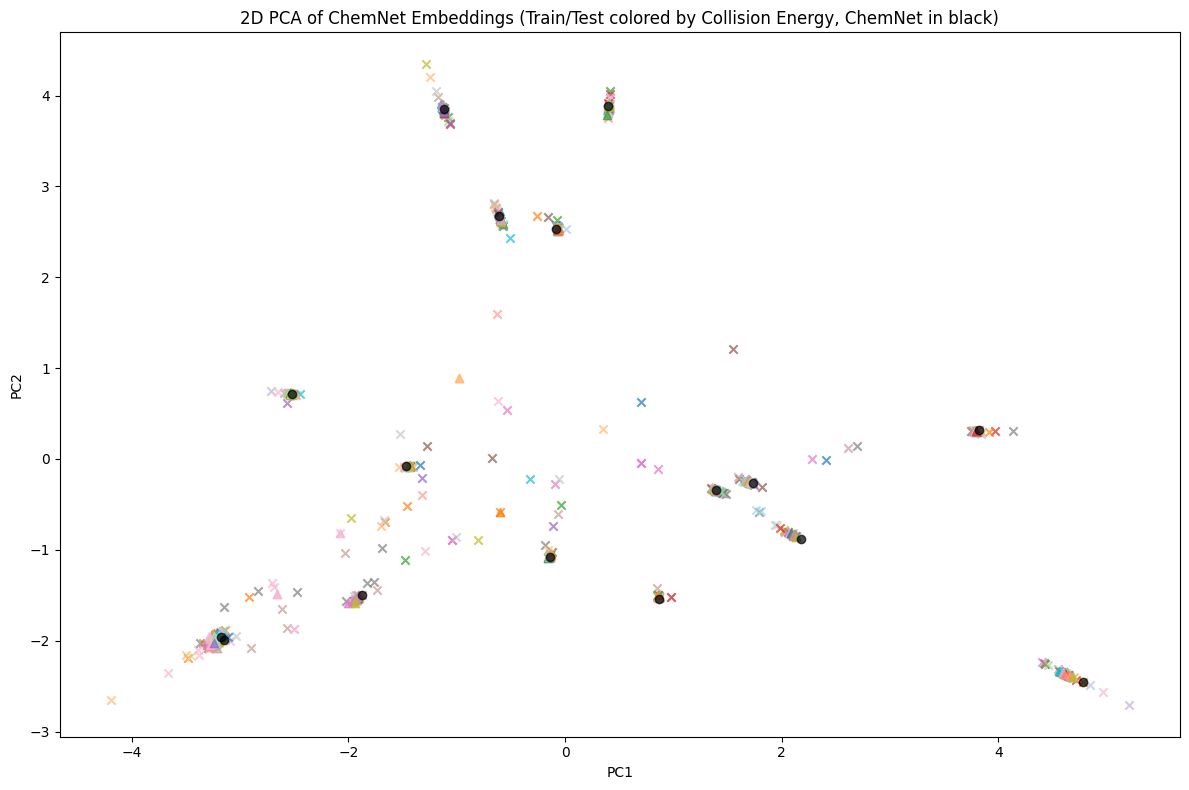

In [129]:
# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Get unique energies and assign colors (excluding chemnet_sub)
all_energies = pd.concat([
    test_output_df_sub['Collision_Energy'],
    train_output_df_sub['Collision_Energy']
]).unique()
color_map = {group: cm.tab20(i % 20) for i, group in enumerate(all_energies)}

plt.figure(figsize=(12,8))

# Plot test set by energy
for energy in test_output_df_sub['Collision_Energy'].unique():
    mask = test_output_df_sub['Collision_Energy'] == energy
    plt.scatter(
        X_output_pca[mask, 0], X_output_pca[mask, 1],
        c=[color_map[energy]], marker='x', label=f'test: {energy}', alpha=0.7
    )

# Plot train set by energy
for energy in train_output_df_sub['Collision_Energy'].unique():
    mask = train_output_df_sub['Collision_Energy'] == energy
    plt.scatter(
        X_train_output_pca[mask, 0], X_train_output_pca[mask, 1],
        c=[color_map[energy]], marker='^', label=f'train: {energy}', alpha=0.7
    )

# Plot chemnet set as black
plt.scatter(
    X_chemnet_pca[:, 0], X_chemnet_pca[:, 1],
    c='black', marker='o', label='chemnet_sub', alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test colored by Collision Energy, ChemNet in black)')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

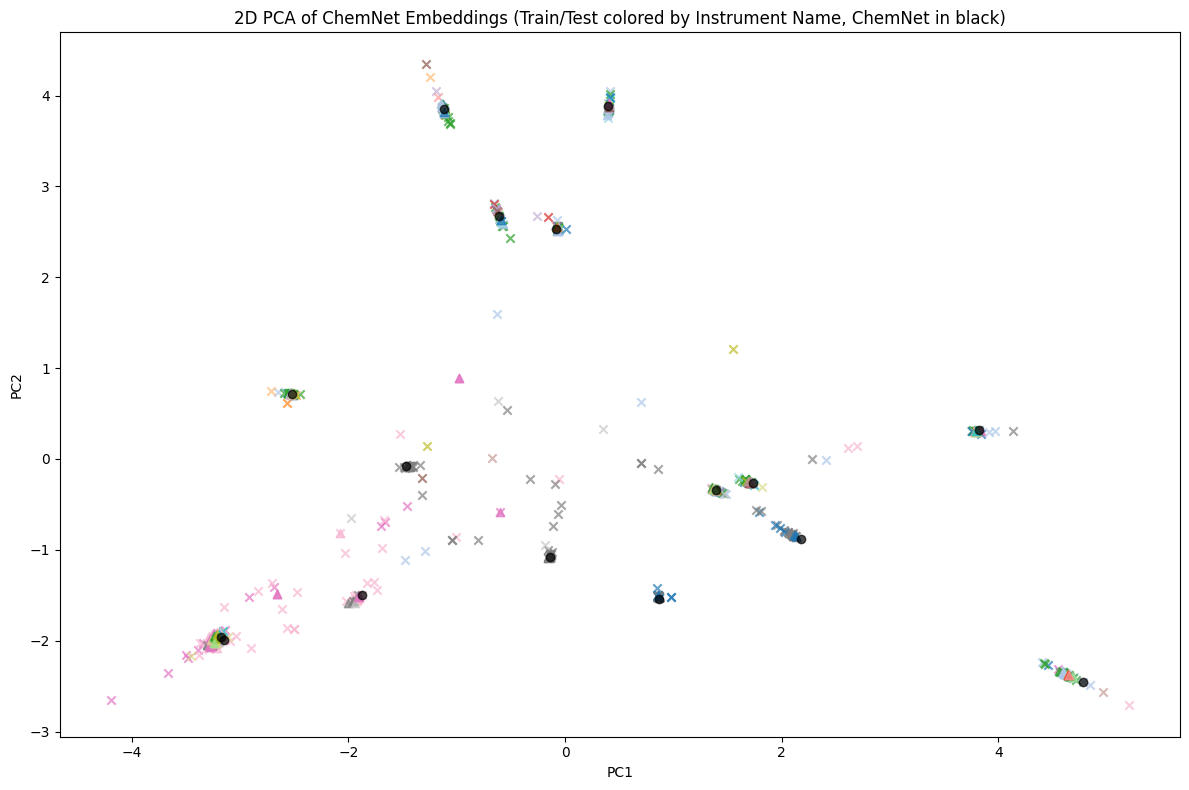

In [130]:
# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Get unique Inames and assign colors (excluding chemnet_sub)
all_Inames = pd.concat([
    test_output_df_sub['Instrument_Name'],
    train_output_df_sub['Instrument_Name']
]).unique()
color_map = {Itype: cm.tab20(i % 20) for i, Itype in enumerate(all_Inames)}

plt.figure(figsize=(12,8))

# Plot test set by Iname
for Iname in test_output_df_sub['Instrument_Name'].unique():
    mask = test_output_df_sub['Instrument_Name'] == Iname
    plt.scatter(
        X_output_pca[mask, 0], X_output_pca[mask, 1],
        c=[color_map[Iname]], marker='x', label=f'test: {Iname}', alpha=0.7
    )

# Plot train set by Iname
for Iname in train_output_df_sub['Instrument_Name'].unique():
    mask = train_output_df_sub['Instrument_Name'] == Iname
    plt.scatter(
        X_train_output_pca[mask, 0], X_train_output_pca[mask, 1],
        c=[color_map[Iname]], marker='^', label=f'train: {Iname}', alpha=0.7
    )

# Plot chemnet set as black
plt.scatter(
    X_chemnet_pca[:, 0], X_chemnet_pca[:, 1],
    c='black', marker='o', label='chemnet_sub', alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test colored by Instrument Name, ChemNet in black)')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

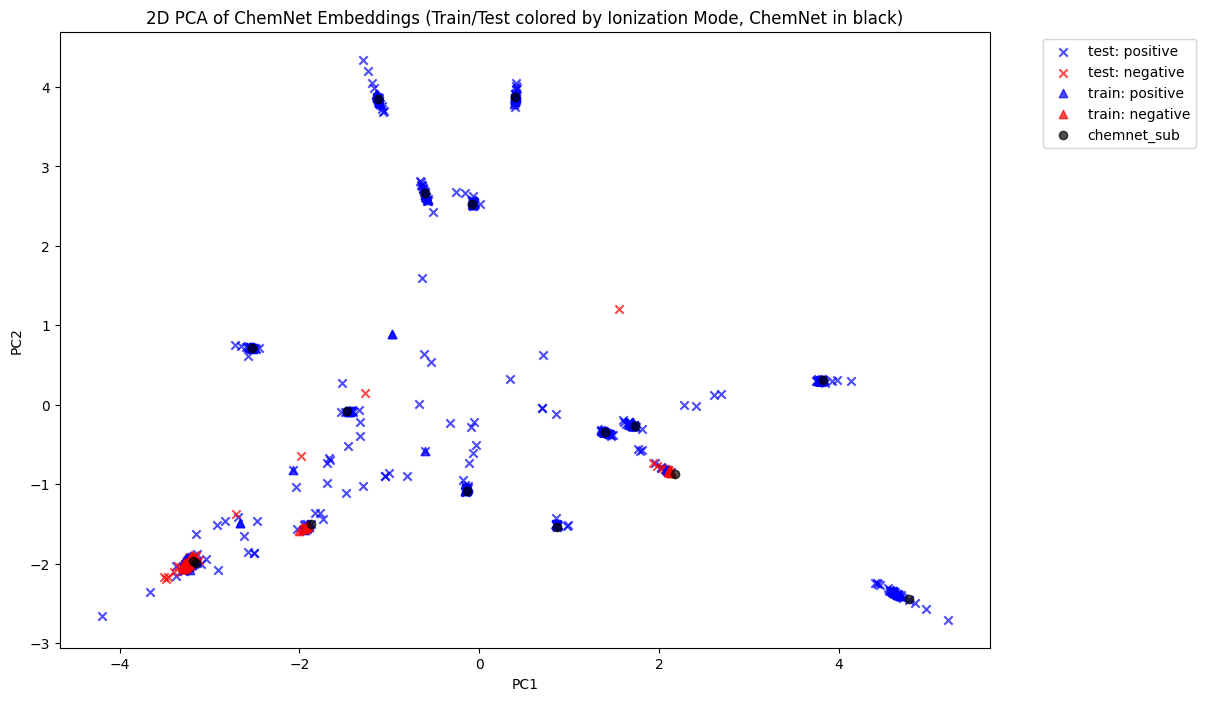

In [131]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign red and blue to the two unique Ionization Modes
unique_modes = pd.concat([
    test_output_df_sub['Ionization_Mode'],
    train_output_df_sub['Ionization_Mode']
]).unique()

# Assign colors: first mode is blue, second is red
mode_colors = {mode: color for mode, color in zip(unique_modes, ['blue', 'red'])}

plt.figure(figsize=(12,8))

# Plot test set by mode
for mode in test_output_df_sub['Ionization_Mode'].unique():
    mask = test_output_df_sub['Ionization_Mode'] == mode
    plt.scatter(
        X_output_pca[mask, 0], X_output_pca[mask, 1],
        c=mode_colors[mode], marker='x', label=f'test: {mode}', alpha=0.7
    )

# Plot train set by mode
for mode in train_output_df_sub['Ionization_Mode'].unique():
    mask = train_output_df_sub['Ionization_Mode'] == mode
    plt.scatter(
        X_train_output_pca[mask, 0], X_train_output_pca[mask, 1],
        c=mode_colors[mode], marker='^', label=f'train: {mode}', alpha=0.7
    )

# Plot chemnet set as black
plt.scatter(
    X_chemnet_pca[:, 0], X_chemnet_pca[:, 1],
    c='black', marker='o', label='chemnet_sub', alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test colored by Ionization Mode, ChemNet in black)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

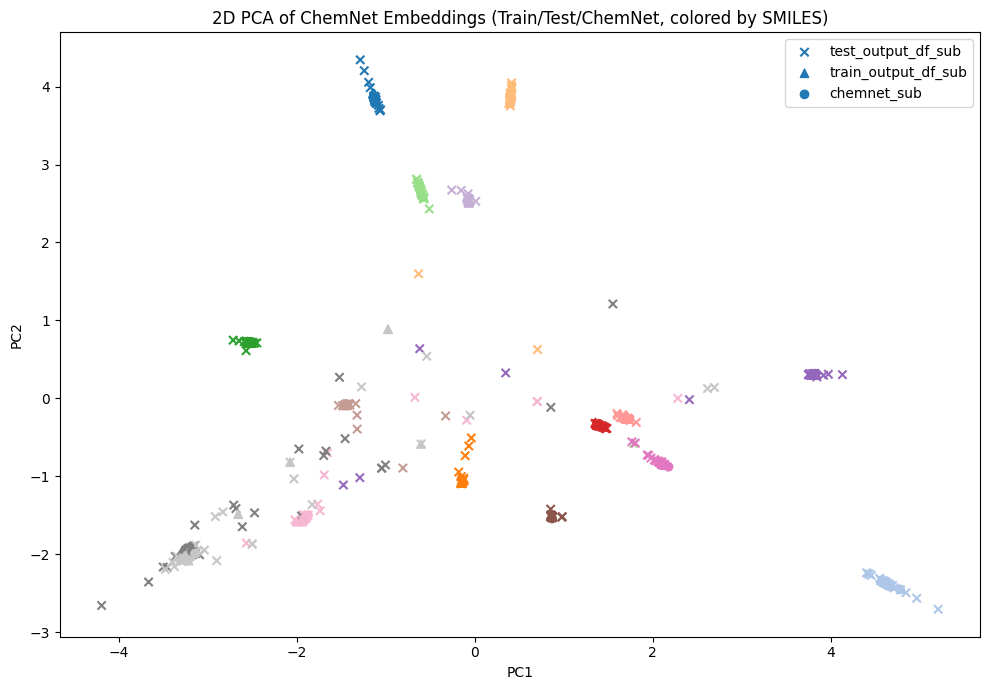

In [132]:
# PCA plot, color by SMILES (with train data plotted)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split 
X_test_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

output_colors = test_output_df_sub['SMILES_spectra'].map(color_map)
train_colors = train_output_df_sub['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_sub['SMILES'].map(color_map)

# Plot
plt.figure(figsize=(10,7))

plt.scatter(X_output_pca[:,0], X_output_pca[:,1], 
            c=output_colors, marker='x', label='test_output_df_sub', alpha=0.99)
plt.scatter(X_train_output_pca[:,0], X_train_output_pca[:,1], 
            c=train_colors, marker='^', label='train_output_df_sub', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='chemnet_sub', alpha=0.99)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by SMILES)')
plt.tight_layout()
plt.legend()
plt.show()